In [2]:
import pandas as pd



In [3]:
from google.colab import files

uploaded = files.upload()

Saving cohort_index_dataset.csv to cohort_index_dataset.csv


In [4]:
df = pd.read_csv("cohort_index_dataset.csv")

In [5]:
customer_summary = df.groupby("Customer ID").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Orders=("Invoice", "nunique"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

customer_summary.head()

,Customer ID,Total_Revenue,Total_Orders,Total_Quantity
0,12346.0,-64.68,17,52
1,12347.0,5408.50,7,3094
2,12348.0,2019.40,5,2714
3,12349.0,4404.54,5,1619
4,12350.0,334.40,1,197


In [6]:
customer_summary["Customer_Type"] = "Regular"

customer_summary.loc[
    customer_summary["Total_Revenue"] >= customer_summary["Total_Revenue"].quantile(0.75),
    "Customer_Type"
] = "High Value"

customer_summary.loc[
    customer_summary["Total_Revenue"] <= customer_summary["Total_Revenue"].quantile(0.25),
    "Customer_Type"
] = "Low Value"

In [7]:
customer_summary["Customer_Type"].value_counts()

,count
Customer_Type,
Regular,2962
Low Value,1481
High Value,1481


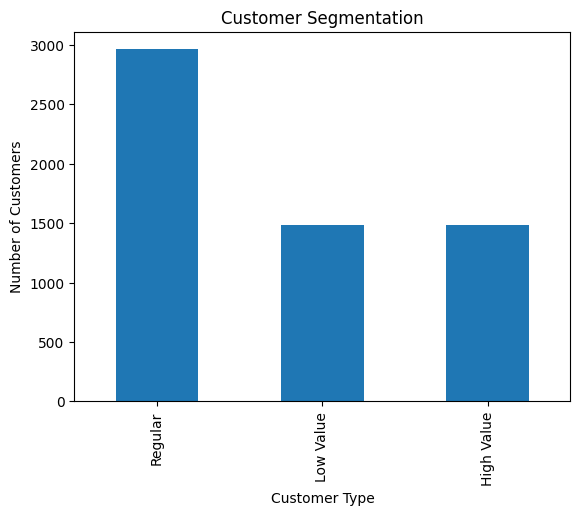

In [8]:
import matplotlib.pyplot as plt

customer_summary["Customer_Type"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
customer_summary.to_csv(
    "customer_segmentation.csv",
    index=False
)

In [10]:
from google.colab import files

files.download("customer_segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>